# Predicting US Soybean Yields Using State-Level Data

## Objective

Train a basic ML model in Python to predict annual soybean yields in the US on a state level.


## Work environment setup

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import linregress

from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import r2_score, root_mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OneHotEncoder
from sklearn.inspection import permutation_importance

from src.viz.heatmap import plot_clustered_heatmap



## Exploratory Data Analysis

Shape: (554, 3)

Data types:
state_name        str
year            int64
yield         float64
dtype: object

NaN counts:
state_name    0
year          0
yield         0
dtype: int64

Descriptive stats:
       state_name         year       yield
count         554   554.000000  554.000000
unique         32          NaN         NaN
top       ALABAMA          NaN         NaN
freq           18          NaN         NaN
mean          NaN  2013.420578   41.136282
std           NaN     5.147904   10.031502
min           NaN  2005.000000    0.000000
25%           NaN  2009.000000   35.000000
50%           NaN  2013.000000   42.000000
75%           NaN  2018.000000   48.000000
max           NaN  2022.000000   65.000000



<Axes: xlabel='state_name'>

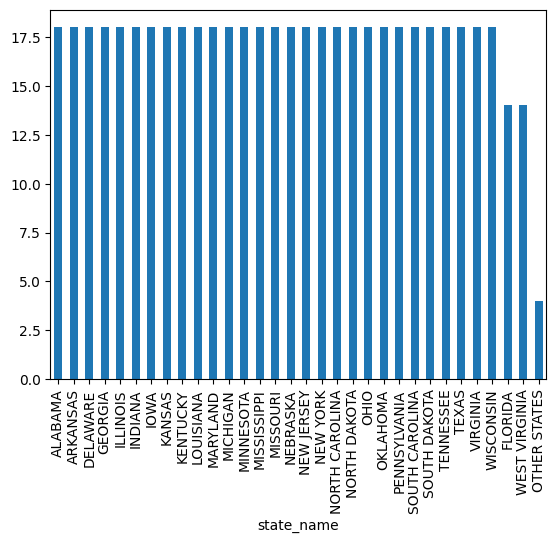

In [2]:
yield_df = pd.read_csv("data/yield.csv")
print(f"Shape: {yield_df.shape}\n")
print(f"Data types:\n{yield_df.dtypes}\n")
print(f"NaN counts:\n{yield_df.isna().sum()}\n")
print(f"Descriptive stats:\n{yield_df.describe(include='all')}\n")
yield_df.value_counts("state_name").plot(kind="bar")

There are 32 state levels covering an 18 year timeseries. The dataset is relatively complete, except for Florida and West Virginia that only have data for 14 years of data (2005 to 2018), while the label "Other States" only have 4 years of data (2015 to 2018).

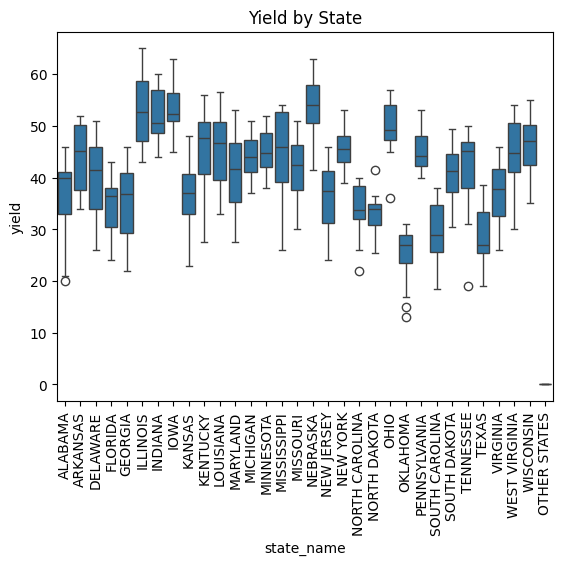

In [3]:
sns.boxplot(data=yield_df, x='state_name', y='yield')
plt.xticks(rotation=90)
plt.title('Yield by State')
plt.show()

The top 4 soybean yield states are Illinois, Iowa, Indiana and Nebraska, while the lowest yielding states are Oklahoma, Texas and South Carolina.

The "Other states" are an outlier with yield at 0 bushels per acre (bu/A) and will be dropped from the analysis.

In [4]:
# Preprocessing: Remove "OTHER STATES"
yield_df = yield_df[yield_df["state_name"] != "OTHER STATES"].reset_index(drop=True)

mean_yield = yield_df['yield'].mean()
std_yield = yield_df['yield'].std()
cv_yield = (std_yield / mean_yield) * 100

# Display results
print(f"Mean Yield: {mean_yield:.1f} bu/A")
print(f"Standard Deviation: {std_yield:.1f} bu/A")
print(f"Coefficient of Variation: {cv_yield:.1f}%")

Mean Yield: 41.4 bu/A
Standard Deviation: 9.4 bu/A
Coefficient of Variation: 22.8%


In [5]:
tp_df = pd.read_csv("data/tp.csv")
tmax_df = pd.read_csv("data/2t.csv")

weather_df = tp_df.merge(tmax_df, on=["state_name", "date"])
weather_df["date"] = pd.to_datetime(weather_df["date"])

print(f"Shape: {weather_df.shape}\n")
print(f"Data types:\n{weather_df.dtypes}\n")
print(f"NaN counts:\n{weather_df.isna().sum()}\n")


Shape: (68270, 4)

Data types:
date                   datetime64[us]
state_name                        str
total precipitation           float64
2m max temperature            float64
dtype: object

NaN counts:
date                   0
state_name             0
total precipitation    0
2m max temperature     0
dtype: int64



In [6]:
weather_df = weather_df.rename(columns={'total precipitation': 'total_precipitation_mm'})
weather_df["total_precipitation_mm"] = weather_df["total_precipitation_mm"].round(1)

weather_df['max_temperature_celsius'] = (weather_df['2m max temperature'] - 273.15).round(1)
weather_df = weather_df.drop(columns=['2m max temperature'])

In [7]:
print(f"Descriptive stats:\n{weather_df.describe(include='all')}\n")

Descriptive stats:
                              date state_name  total_precipitation_mm  \
count                        68270      68270            68270.000000   
unique                         NaN         10                     NaN   
top                            NaN   ILLINOIS                     NaN   
freq                           NaN       6827                     NaN   
mean    2014-05-09 20:53:07.110004        NaN                2.527302   
min            2005-01-01 00:00:00        NaN                0.000000   
25%            2009-09-06 00:00:00        NaN                0.000000   
50%            2014-05-10 00:00:00        NaN                0.400000   
75%            2019-01-11 00:00:00        NaN                2.700000   
max            2023-09-19 00:00:00        NaN               59.700000   
std                            NaN        NaN                4.806115   

        max_temperature_celsius  
count              68270.000000  
unique                      NaN  
to

Weather features go from 2005 to 2023, yet 2023 is incomplete (2023-09-19).

In [8]:
available_number_of_days = len(weather_df["date"].unique())

min_date = weather_df["date"].min()
max_date = weather_df["date"].max()
complete_range = pd.date_range(start=min_date, end=max_date, freq="D")
expected_number_of_days = len(complete_range)

available_number_of_days = len(weather_df["date"].unique())

print(f"There are {available_number_of_days} unique dates in the dataset yet we would expect {expected_number_of_days} days between {min_date.date()} and {max_date.date()}.")
print(f"This means there are {expected_number_of_days - available_number_of_days} missing days in the dataset.")    

missing_dates = complete_range.difference(weather_df["date"])
print("Missing dates:")
print(missing_dates)


There are 6827 unique dates in the dataset yet we would expect 6836 days between 2005-01-01 and 2023-09-19.
This means there are 9 missing days in the dataset.
Missing dates:
DatetimeIndex(['2007-12-29', '2007-12-30', '2007-12-31', '2020-07-30',
               '2020-07-31', '2023-07-30', '2023-07-31', '2023-09-12',
               '2023-09-13'],
              dtype='datetime64[us]', freq=None)


9 days are missing for the 6836 days present in the weather dataframe, 4 of those are in 2023 which will drop from the analyis since yield dataframe only goes upto 2022.

We could impute missing data by calling a weather API and recomputing the aggregated state-level, but the impact should be negligeable for this analysis.

In [9]:
# Preprocessing: Remove 2023 from weather data
weather_df = weather_df[weather_df["date"].dt.year < 2023].reset_index(drop=True)

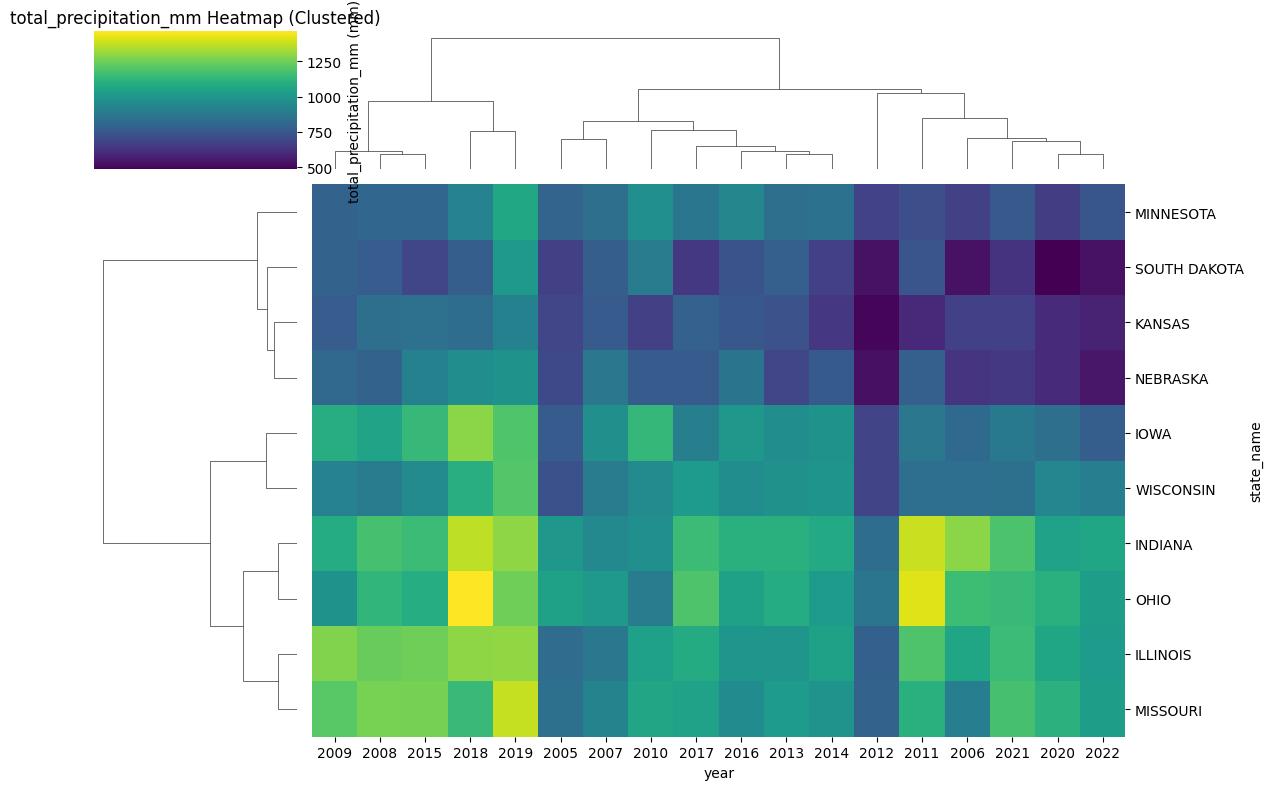

In [10]:
plot_clustered_heatmap(weather_df, 'total_precipitation_mm', freq='YE', agg_func="sum")

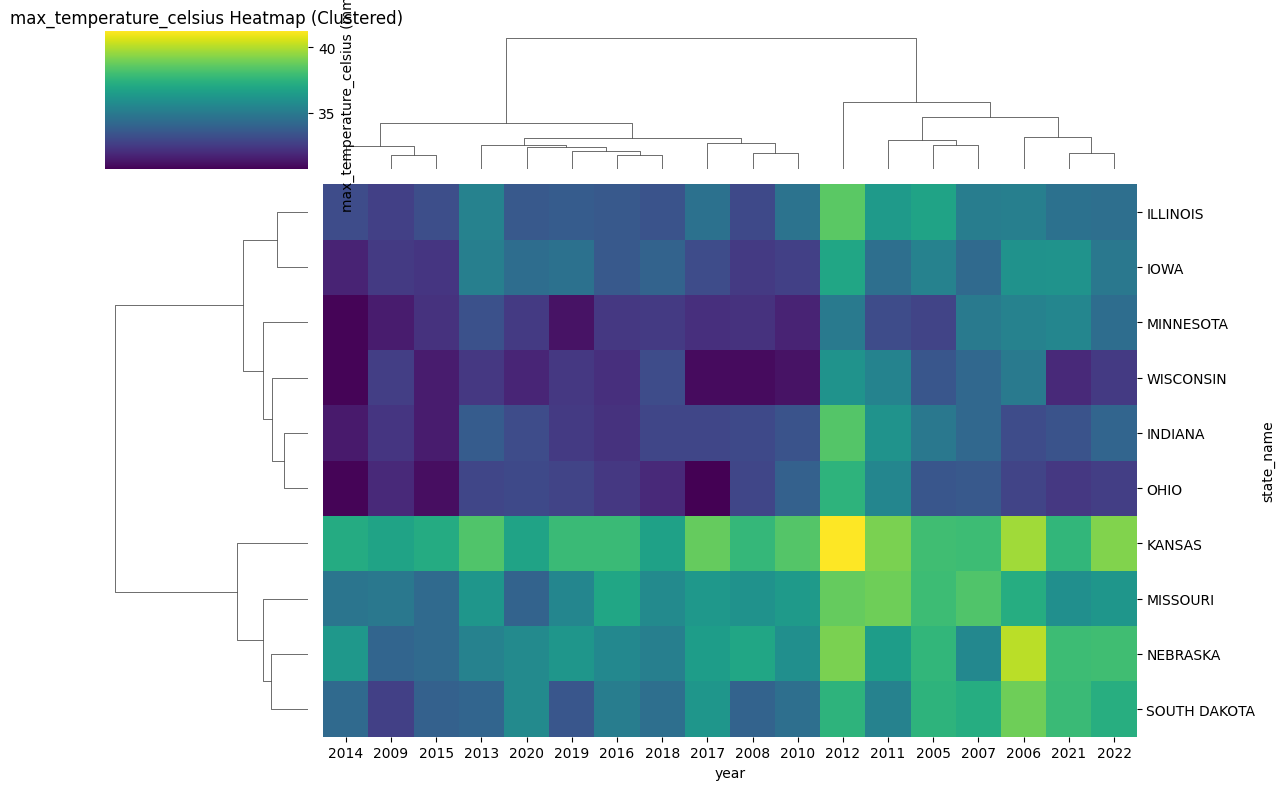

In [11]:
plot_clustered_heatmap(weather_df, 'max_temperature_celsius', freq='YE', agg_func='max')

There are some structural patterns in the weather data. Throughout the considered timeseries, Minnesota, South Dakota, Nebraska and Kansas had the least precipitation, while Minnesota, South Dakota, Nebraska, and Missouri recorded the highest temperatures.  
2012 is dryiest and hottest year which fits with historic drought year that was recorded in the US.

## Modeling strategy strategy

The soybean yield has an increasing trend that can be explained by advancement in technology, improved agronomic practices, and cultivar changes over years. The trend can be visually assessed in the line plot and is statistically significant as shown by the ADF test.


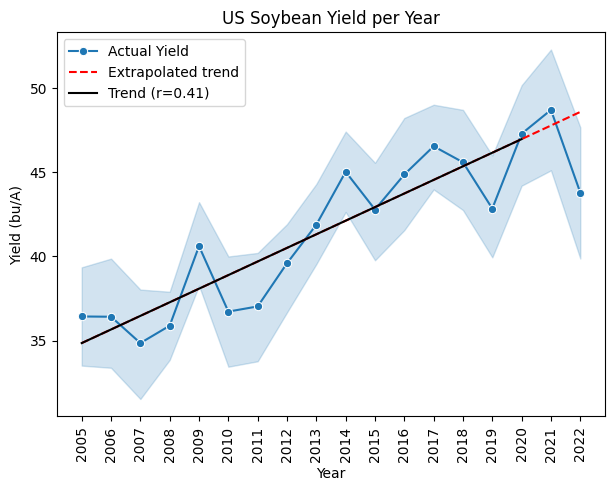

ADF Statistic: -0.9755
p-value: 0.7621


In [12]:
validation_years = [2021, 2022]

sns.lineplot(data=yield_df, x='year', y='yield', marker='o', label='Actual Yield')

mask = ~yield_df['year'].isin(validation_years)
slope, intercept, r_value, p_value, std_err = linregress(
    yield_df.loc[mask, 'year'], yield_df.loc[mask, 'yield']
)

trend_line_full = slope * yield_df['year'] + intercept
trend_line_partial = np.where(mask, trend_line_full, np.nan)

plt.plot(
    yield_df['year'],
    trend_line_full,
    color='red',
    linestyle='--',
    linewidth=1.5,
    label='Extrapolated trend'
)
plt.plot(
    yield_df['year'],
    trend_line_partial,
    color='black',
    linestyle='-',
    linewidth=1.5,
    label=f'Trend (r={r_value:.2f})'
)

plt.title('US Soybean Yield per Year')
plt.xlabel('Year')
plt.ylabel('Yield (bu/A)')
plt.legend()
plt.tight_layout()
plt.xticks(np.arange(int(yield_df['year'].min()), int(yield_df['year'].max()) + 1, 1), rotation=90)
plt.show()

yield_aggregated = yield_df.groupby('year')['yield'].mean().reset_index().sort_values('year')
adf_result = adfuller(yield_aggregated['yield'])
print('ADF Statistic:', adf_result[0].round(4))
print('p-value:', adf_result[1].round(4))

It is common procedure to detrend the yield before modeling it (Joshi et al., 2020 and Li et al., 2023).

We will compare a baseline model, which averages the historical detrended yield across states, to our ML pilot model.

Since the weather data is only available for 10 states, we will only be assessing those in the model comparison. The rest of 21 states will have to rely on the baseline model. If the ML model is conclusive we would explore methods to extract the missing features to apply our ML solution. We will discuss this further in the perspectives section.  

In [13]:
states_of_interest = weather_df["state_name"].unique().tolist()
print(f"The {len(states_of_interest)} states of interest are: {', '.join(states_of_interest)}")

# Create a custom palette: states_of_interest get distinct colors
soi_palette = {state: color for state, color in zip(states_of_interest, sns.color_palette("colorblind", n_colors=len(states_of_interest)))}
palette = soi_palette.copy()
palette.update({state: 'black' for state in yield_df['state_name'].unique() if state not in states_of_interest})


The 10 states of interest are: ILLINOIS, IOWA, KANSAS, NEBRASKA, SOUTH DAKOTA, OHIO, WISCONSIN, INDIANA, MISSOURI, MINNESOTA


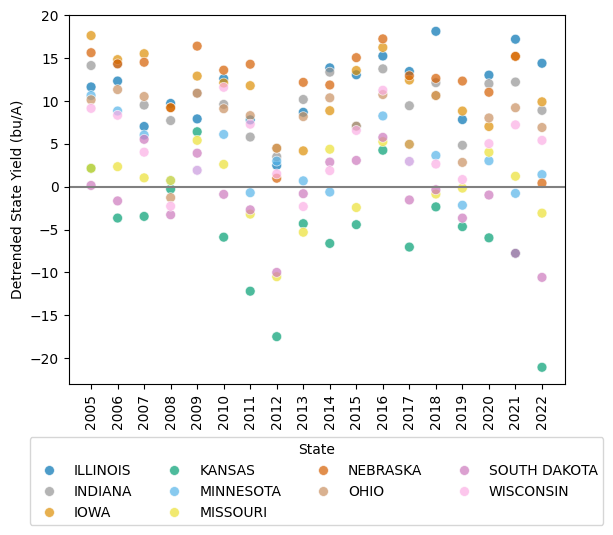

In [14]:
yield_df['yield_trend'] = intercept + slope * yield_df['year']
yield_df['yield_detrended'] = yield_df['yield'] - yield_df['yield_trend']

mask = yield_df["state_name"].isin(states_of_interest)
sns.scatterplot(
    x=yield_df['year'][mask],
    y=yield_df['yield_detrended'][mask],
    hue=yield_df['state_name'][mask],
    palette=soi_palette,
    s=50,
    alpha=0.7
)
plt.axhline(y=0, color='grey', linestyle='-')
plt.xlabel(None)
plt.ylabel('Detrended State Yield (bu/A)')
plt.xticks(np.arange(int(yield_df['year'].min()), int(yield_df['year'].max()) + 1, 1), rotation=90)
plt.legend(
    title='State',
    loc='lower center',
    bbox_to_anchor=(0.5, -0.4),
    ncol=4
)
plt.show()

There seems to be a bias amongst the states of interest, it probably is because amongst those are top US soybean producing states. 

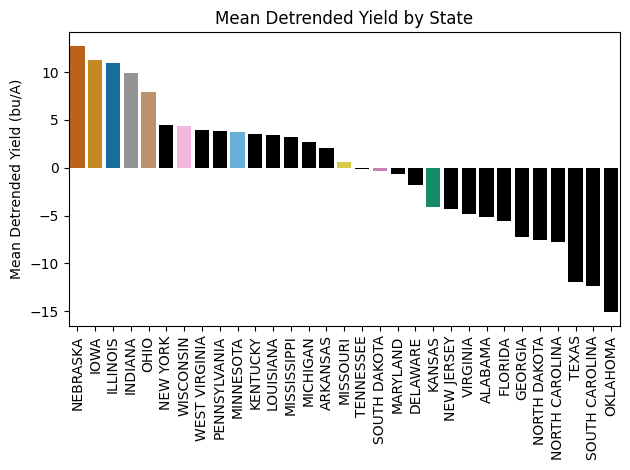

In [15]:
mask = ~yield_df["year"].isin(validation_years)
aggregated_state_detrended_yield = yield_df[mask].groupby('state_name')['yield_detrended'].mean().reset_index().sort_values('yield_detrended', ascending=False)

sns.barplot(
    data=aggregated_state_detrended_yield,
    x='state_name',
    y='yield_detrended',
    hue='state_name',
    palette=palette
)
plt.title('Mean Detrended Yield by State')
plt.xlabel(None)
plt.ylabel('Mean Detrended Yield (bu/A)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

We can classify the soybean yield states as following:
- Top yielding states: Nebraska, Illinois, Iowa, Indiana and Ohio 
- Good yielding states: Wisconsin and Minnesota
- Average yielding states: Missouri and South Dakota
- Lower yielind states: Kansas

*Note that throughout the notebook the states that are not of interest will be assigned the color black.*

## Baseline model

In [16]:
# Calculate baseline predictions for test years: mean detrended yield per state + trend for each year
baseline_pred_list = []
for year in validation_years:
    trend_year = intercept + slope * year
    baseline_pred_year = (aggregated_state_detrended_yield.set_index('state_name')['yield_detrended'] + trend_year).round(1)
    baseline_pred_year = baseline_pred_year.reset_index().assign(year=year).rename(columns={'yield_detrended': 'predicted_yield'})
    baseline_pred_list.append(baseline_pred_year)

baseline_pred = pd.concat(baseline_pred_list).sort_values(['year', 'predicted_yield'], ascending=[True, False])

# Actual yields for test years
actual = yield_df[yield_df['year'].isin(validation_years)].groupby(['state_name', 'year'])['yield'].mean().reset_index().sort_values(['year', 'yield'], ascending=[True, False])


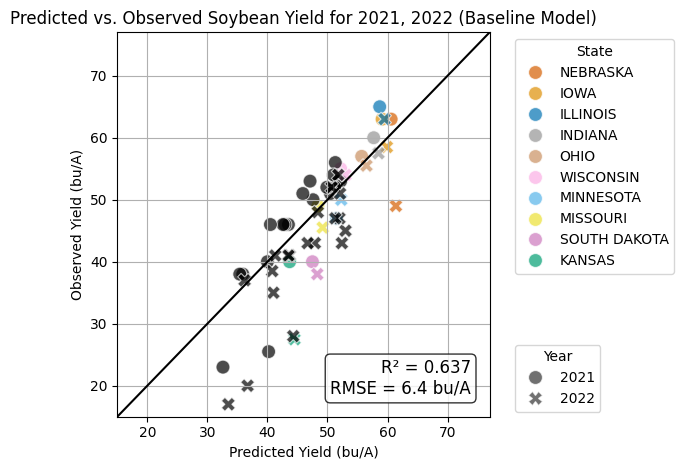

In [17]:
pred_vs_actual = baseline_pred.merge(actual, on=['state_name', 'year'], suffixes=('_pred', '_actual'))

r2 = r2_score(pred_vs_actual['yield'], pred_vs_actual['predicted_yield'])
rmse = root_mean_squared_error(pred_vs_actual['yield'], pred_vs_actual['predicted_yield'])

ax = sns.scatterplot(
    data=pred_vs_actual,
    x='predicted_yield',
    y='yield',
    hue='state_name',
    style='year',
    palette=palette,
    s=100,
    alpha=0.7,
)

# Add 1:1 line
min_val = min(pred_vs_actual['predicted_yield'].min(), pred_vs_actual['yield'].min())-2
max_val = max(pred_vs_actual['predicted_yield'].max(), pred_vs_actual['yield'].max())+12
plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    color='black',
    linestyle='-',
    label='1:1 Line'
)

plt.title(f'Predicted vs. Observed Soybean Yield for {", ".join(map(str, validation_years))} (Baseline Model)')
plt.xlabel('Predicted Yield (bu/A)')
plt.ylabel('Observed Yield (bu/A)')
plt.grid(True)
plt.xlim(min_val, max_val)
plt.ylim(min_val, max_val)
plt.text(
    0.95, 0.15, f'R² = {r2:.3f}\nRMSE = {rmse:.1f} bu/A',
    transform=plt.gca().transAxes,
    fontsize=12,
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8),
    ha="right", va="top"
)

# Get legend handles/labels
handles, labels = ax.get_legend_handles_labels()

# Split into state and year entries
state_handles = []
state_labels = []
year_handles = []
year_labels = []

for h, l in zip(handles, labels):
    if l in states_of_interest:
        state_handles.append(h)
        state_labels.append(l)
    elif l in map(str, pred_vs_actual['year'].unique()):
        year_handles.append(h)
        year_labels.append(l)

# First legend: year (style)
legend1 = plt.legend(
    handles=year_handles,
    labels=year_labels,
    title='Year',
    bbox_to_anchor=(1.05, 0.1),
    loc='center left'
)
# Add it manually so it doesn't get overwritten
plt.gca().add_artist(legend1)

# Second legend: state (hue)
plt.legend(
    handles=state_handles,
    labels=state_labels,
    title='State',
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.tight_layout()
plt.show()

The baseline model, which uses the mean detrended yield per state plus the overall extrapolated trend for the test years, achieves an R² of 0.638 and an RMSE of 6.4 bu/A when predicting the actual yields for the test years.

There seems to be an overall underprediction for 2022 with some states more impacted than other such as Kansas, South Dakota and more notably Nebraska which is a top producing state.

The baseline model appears to be prone to year-specific bias, which is expected given that it does not incorporate any weather-related information.

## Pilot ML model

### Model selection

We could have leveraged the `pycaret` library to do an agnostic model selection. However in the context of the technical test I have decided to do an opinionated model selection.

I will train a Random Forest (RF) due to its simplicity, interpretability, and robustness to overfitting. It is a standard choice for tabular data and can capture nonlinear relationships without extensive feature engineering.

### Feature Engineering

Ensemble models such as RF do not require feature normalization or scaling, we can jump straight to feature engineering.

Soybean yield is sensitive to heat stress (Onat et al., 2017) and water stress (Lesk et al., 2016) primarily. 

We will focus on designing features related to those as follows:
- number of days above a 35°C threshold (Onat et al., 2025)
- number of consecutive days without rain (<= 1mm)

In addition we will compute some additional proxy features:
- an interaction feature between temperature and precipitation as well as the number of consecutive rainy days (> 1mm) as proxies for biotic stresses (cryptogamic)
- one hot encoding of states to account for spatially structured, time-independent factors such as soil properties and crop practices.

All of those features will be aggregated at key development periods for soybean. In the absence of a phenology model integration, we will aggregate those to the typical vegetative (April-June) and reproductive (July-September) periods in the US. Soybean is known to have some complex compensation mechanisms in it's yield establishment and is relatively robust to abiotic stresses during it's vegetative phase.

*Disclaimer:
Alternative temporal aggregation schemes (biweekly and monthly windows) were also evaluated. However, aggregating at the crop's developmental scale, as described above, provided the best predictive performance while improving interpretability.*


In [18]:
# Subset to a fixed April-to-September growing season and align all state years to the same periods
season_start_month = 4
season_end_month = 9

growing_season_df = weather_df[
    (weather_df['date'].dt.month >= season_start_month) &
    (weather_df['date'].dt.month <= season_end_month)
].copy()

growing_season_df['year'] = growing_season_df['date'].dt.year
season_start = pd.to_datetime(growing_season_df['year'].astype(str) + '-04-01')
season_day = (growing_season_df['date'] - season_start).dt.days

growing_season_df = growing_season_df[(season_day >= 0) & (season_day < 184)].copy()

growing_season_df['month'] = growing_season_df['date'].dt.month

# Define growing periods: v (Vegetative, April-June), r (Reproductive, July-September)
growing_season_df['period'] = growing_season_df['month'].map({
    4: 'v',
    5: 'v',
    6: 'v',
    7: 'r',
    8: 'r',
    9: 'r'
})

# Feature engineer daily variables

# Days above 35°C (daily)
growing_season_df['above_35'] = (
    growing_season_df['max_temperature_celsius'] > 35
).astype(int)

# Interaction feature: temperature * precipitation as proxy for biotic cryptogamic stress
growing_season_df['heat_precip_interaction'] = (
    growing_season_df['max_temperature_celsius'] * growing_season_df['total_precipitation_mm']
)

# Drought stress proxies
growing_season_df['is_dry'] = (growing_season_df['total_precipitation_mm'] < 1).astype(int)
growing_season_df['has_rain'] = (growing_season_df['total_precipitation_mm'] > 1).astype(int)

def compute_max_consec(dry):
    dry = dry.fillna(False).astype(bool)
    
    if not dry.any():
        return 0
    
    groups = (dry != dry.shift()).cumsum()
    streak_lengths = dry.groupby(groups).sum()
    
    return streak_lengths.max()

# Aggregate to period-based groups
aggregated_df = (
    growing_season_df
    .groupby(['state_name', 'year', 'period'], as_index=False)
    .agg(
        max_temperature_celsius=('max_temperature_celsius', 'max'),
        total_precipitation_mm=('total_precipitation_mm', 'sum'),
        heat_precip_interaction=('heat_precip_interaction', 'max'),
        days_above_35C=('above_35', 'sum'),
        max_dry_consec=('is_dry', compute_max_consec),
        num_wet_days=('has_rain', 'sum'),
    )
    .rename(columns={'above_35': 'days_above_35C'})
    .round({
        'max_temperature_celsius': 1,
        'total_precipitation_mm': 1,
        'heat_precip_interaction': 0,
        'max_dry_consec': 0,
        'num_wet_days': 0,
    })
)

# Extract year and create pivot tables for period-based features per state and year
# Create a pivot table for each weather feature
feature_alias = {
    'max_temperature_celsius': 'max_temp',
    'total_precipitation_mm': 'total_precip',
    'heat_precip_interaction': 'heat_precip_inter',
    'days_above_35C': 'days_above_35C',
    'max_dry_consec': 'max_dry_consec',
    'num_wet_days': 'num_wet_days',
}
aggregated_df = aggregated_df.rename(columns=feature_alias)
features_to_pivot = feature_alias.values()

pivot_frames = []
for feature in features_to_pivot:
    prefix = feature_alias.get(feature, feature)
    feature_pivot = (
        aggregated_df
        .pivot_table(
            index=['state_name', 'year'],
            columns='period',
            values=feature,
            aggfunc='first'
        )
        .rename(columns=lambda col: f'{prefix}_{col}')
    )
    pivot_frames.append(feature_pivot)

pivot_df = pd.concat(pivot_frames, axis=1).reset_index()

print(f"Pivot table shape: {pivot_df.shape}")

Pivot table shape: (180, 14)


We will then explore a correlation matrix with the engineered features and our target of interest, the **detrended_yield**. 

Absence of correlation with the target could indicate weak marginal relationships between individual features and the target.

We also explore potential collinearity among predictors. While RF are generally robust to multicollinearity in terms of predictive performance, correlated features can affect feature importance interpretation. This analysis may therefore provide additional agronomic insight, for example in assessing redundancy or overlap between features derived from different growing periods.

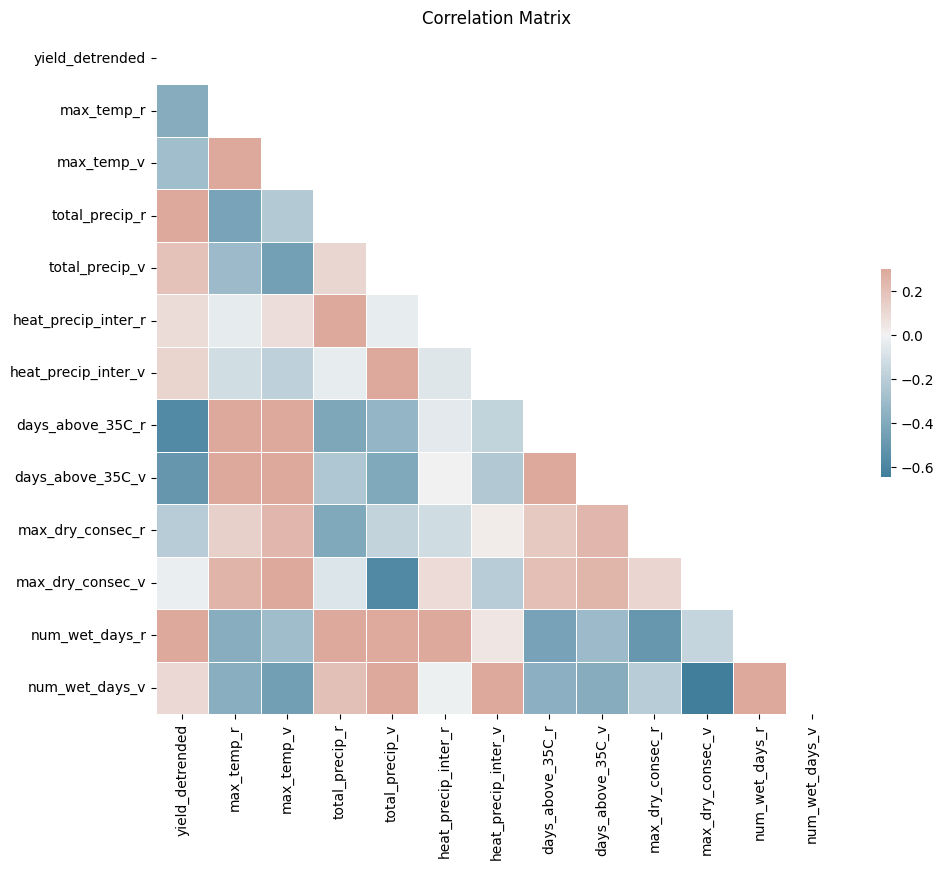

In [19]:
features= [
    col for col in pivot_df.columns
    if any(key in col for key in feature_alias.values())
]
df = yield_df.merge(pivot_df, on=['state_name', 'year'], how='inner')

corr = df[["yield_detrended"] + features].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

# Set up the matplotlib figure
f, ax = plt.subplots(figsize=(11, 9))

# Generate a custom diverging colormap
cmap = sns.diverging_palette(230, 20, as_cmap=True)

# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(corr, mask=mask, cmap=cmap, vmax=.3, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .3})
plt.title("Correlation Matrix")
plt.show()

As expected there is a lot of collinearity between the weather features, which comforts are RF model selection since it is inherently robust to multicollinearity.


In [20]:
# Preprocessing: Remove columns with zero variance

cols_without_variance = df[["yield_detrended"] + features].columns[df[["yield_detrended"] + features].var() == 0].tolist()
print(f"Columns with zero variance to be dropped: {cols_without_variance}")

df = df.drop(columns=cols_without_variance).reset_index(drop=True)
features = [col for col in features if col not in cols_without_variance]    
print("Final dataset shape after preprocessing:", df.shape)


Columns with zero variance to be dropped: []
Final dataset shape after preprocessing: (180, 17)


In [21]:

train_df = df[~df['year'].isin(validation_years)].reset_index(drop=True)
test_df = df[df['year'].isin(validation_years)].reset_index(drop=True) 

encoder = OneHotEncoder(sparse_output=False, drop='first')

train_df_encoded = train_df.copy()
test_df_encoded = test_df.copy()

encoder.fit(train_df[['state_name']])

train_encoded = encoder.transform(train_df[['state_name']])
test_encoded = encoder.transform(test_df[['state_name']])

encoded_cols = [f'state_{cat}' for cat in encoder.categories_[0][1:]]
train_encoded_df = pd.DataFrame(train_encoded, columns=encoded_cols, index=train_df.index)
test_encoded_df = pd.DataFrame(test_encoded, columns=encoded_cols, index=test_df.index)

train_df_encoded = pd.concat([train_df_encoded, train_encoded_df], axis=1)
test_df_encoded = pd.concat([test_df_encoded, test_encoded_df], axis=1)

features_encoded = features + encoded_cols

Finally the detrended yield seems negatively correlated with `max_temp` related features and positively correlated with `total_precip` related features.

## Random Forest training

Since the yield is detrended, we have reduced long-term trends, ,nevertheless temporal dependencies may still remain. We therefore apply a Leave-One-Year-Out cross-validation to avoid leakage between observations from the same year.

Given the small size of our training dataset we will skip hyperparameter tuning to avoid overfitting, we will directly select conservative hyperparameters.

In [22]:
# Initialize RF
rf = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)

# Extract features and target from encoded training data
X = train_df_encoded[features_encoded]
y = train_df_encoded["yield_detrended"]


LOYO CV RMSE: 4.55 ± 1.02


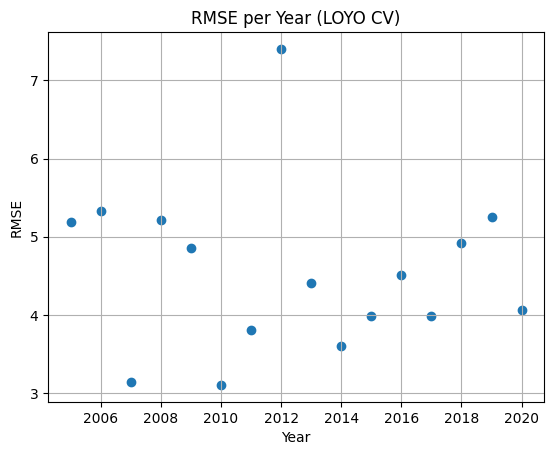

In [23]:
# Leave-One-Year-Out (LOYO) cross-validation
years = sorted(train_df_encoded['year'].unique())

rmse_scores = []
rmse_per_year = {}

for left_out_year in years:
    train_idx = train_df_encoded[train_df_encoded['year'] != left_out_year].index
    test_idx = train_df_encoded[train_df_encoded['year'] == left_out_year].index

    X_train_fold = X.loc[train_idx]
    y_train_fold = y.loc[train_idx]
    X_test_fold = X.loc[test_idx]
    y_test_fold = y.loc[test_idx]
    
    rf.fit(X_train_fold, y_train_fold)
    y_pred_year = rf.predict(X_test_fold)
    
    rmse_test_year = root_mean_squared_error(y_test_fold, y_pred_year)
    rmse_scores.append(rmse_test_year)
    rmse_per_year[left_out_year] = rmse_test_year

rmse_scores = np.array(rmse_scores)

print(f"LOYO CV RMSE: {np.mean(rmse_scores):.2f} ± {np.std(rmse_scores):.2f}")

# Scatter plot of RMSE per year
plt.scatter(rmse_per_year.keys(), rmse_per_year.values())
plt.xlabel("Year")
plt.ylabel("RMSE")
plt.title("RMSE per Year (LOYO CV)")
plt.grid(True)
plt.show()

The 2012 predictions show significantly higher error rates, suggesting the model struggles to capture the unique dynamics of this exceptional drought year across the U.S. 

This could indicate we need need to design better drought indicator features.

In [24]:
rf.fit(train_df_encoded[features_encoded], train_df_encoded["yield_detrended"])
rf_pred_detrended = rf.predict(test_df_encoded[features_encoded])

# Add trend back to the predicted detrended yield
rf_pred_yield = rf_pred_detrended + (intercept + slope * test_df_encoded['year'].values).round(1)

rf_pred = test_df_encoded[['state_name', 'year']].copy()
rf_pred['predicted_yield'] = rf_pred_yield.round(1)

pred_vs_actual_rf = rf_pred.merge(actual, on=['state_name', 'year'], suffixes=('_pred', '_actual'))

r2_rf = r2_score(pred_vs_actual_rf['yield'], pred_vs_actual_rf['predicted_yield'])
rmse_rf = root_mean_squared_error(pred_vs_actual_rf['yield'], pred_vs_actual_rf['predicted_yield'])

print(f"RF Validation Years: {', '.join(map(str, validation_years))}")
print(f"R²: {r2_rf:.3f}")
print(f"RMSE: {rmse_rf:.2f} bu/A")
print("--------------------------")

# RMSE per validation year
rmse_per_year = (
    pred_vs_actual_rf
    .groupby('year')
    .apply(lambda df: root_mean_squared_error(df['yield'], df['predicted_yield']))
)
rmse_per_year = rmse_per_year.loc[validation_years].sort_index()
print("RMSE per validation year:")
for year, rmse_year in rmse_per_year.items():
    print(f"{year}: {rmse_year:.2f} bu/A")


RF Validation Years: 2021, 2022
R²: 0.606
RMSE: 6.11 bu/A
--------------------------
RMSE per validation year:
2021: 5.69 bu/A
2022: 6.50 bu/A


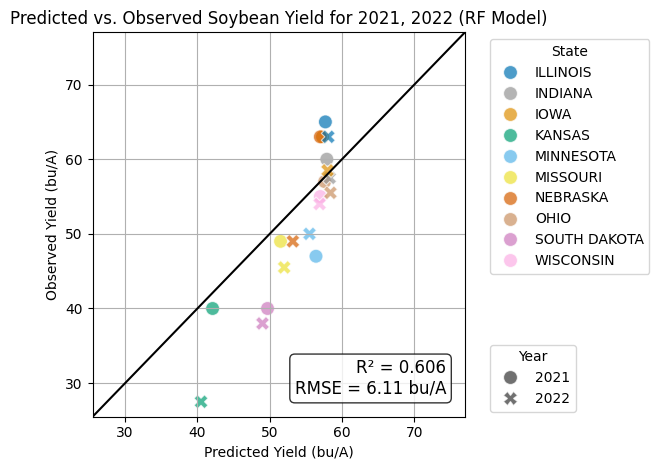

In [25]:
# Scatter plot with RF predictions versus actual 2022 yields
ax = sns.scatterplot(
    data=pred_vs_actual_rf,
    x='predicted_yield',
    y='yield',
    hue='state_name',
    style='year',
    palette=palette,
    s=100,
    alpha=0.7,
)

min_val = min(pred_vs_actual_rf['predicted_yield'].min(), pred_vs_actual_rf['yield'].min()) - 2
max_val = max(pred_vs_actual_rf['predicted_yield'].max(), pred_vs_actual_rf['yield'].max()) + 12
plt.plot([min_val, max_val], [min_val, max_val], color='black', linestyle='-', label='1:1 Line')

plt.title(f'Predicted vs. Observed Soybean Yield for {", ".join(map(str, validation_years))} (RF Model)')
plt.xlabel('Predicted Yield (bu/A)')
plt.ylabel('Observed Yield (bu/A)')
plt.grid(True)
plt.xlim(min_val, max_val)
plt.ylim(min_val, max_val)
plt.text(
    0.95, 0.15, f'R² = {r2_rf:.3f}\nRMSE = {rmse_rf:.2f} bu/A',
    transform=plt.gca().transAxes,
    fontsize=12,
    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8),
    ha='right', va='top'
)

# Get legend handles/labels
handles, labels = ax.get_legend_handles_labels()

# Split into state and year entries
state_handles = []
state_labels = []
year_handles = []
year_labels = []

for h, l in zip(handles, labels):
    if l in states_of_interest:
        state_handles.append(h)
        state_labels.append(l)
    elif l in map(str, pred_vs_actual_rf['year'].unique()):
        year_handles.append(h)
        year_labels.append(l)

# First legend: year (style)
legend1 = plt.legend(
    handles=year_handles,
    labels=year_labels,
    title='Year',
    bbox_to_anchor=(1.05, 0.1),
    loc='center left'
)
# Add it manually so it doesn't get overwritten
plt.gca().add_artist(legend1)

# Second legend: state (hue)
plt.legend(
    handles=state_handles,
    labels=state_labels,
    title='State',
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.tight_layout()
plt.show()


The error is relatively stable across both validation years, even though 2022 is a known poor yield year. This suggests that the RF model captures part of the inter-annual weather signal and its effect on yield.

In addition, the RMSE on validation years (6.10 bu/A) is higher than the LOYO cross-validation estimate (4.55 bu/A), indicating a slight performance drop on unseen years.

The gap suggests mildly optimistic cross-validation, but the increase (+1.5 bu/A) remains moderate and close to the expected standard deviation (1.0 bu/A), indicating reasonable generalization despite some uncaptured inter-annual variability.


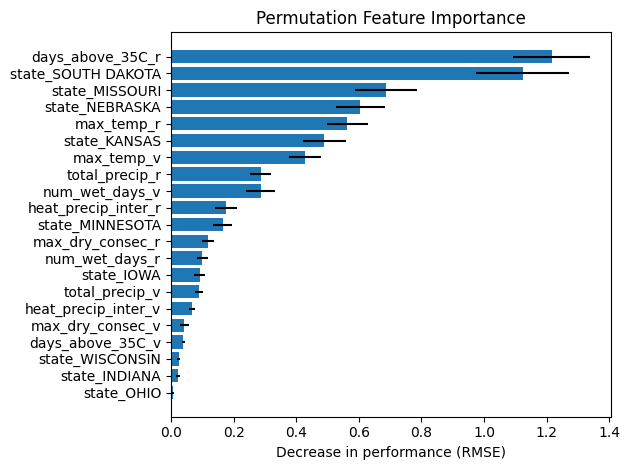

In [26]:
# Compute permutation importance
result = permutation_importance(
    rf, X, y,
    n_repeats=30,
    random_state=42,
    scoring="neg_root_mean_squared_error"
)

# Organize results
importances = pd.DataFrame({
    "feature": X.columns,
    "importance_mean": result.importances_mean,
    "importance_std": result.importances_std
}).sort_values("importance_mean", ascending=True)

# Plot
plt.barh(
    importances["feature"],
    importances["importance_mean"],
    xerr=importances["importance_std"]
)
plt.xlabel("Decrease in performance (RMSE)")
plt.title("Permutation Feature Importance")
plt.tight_layout()
plt.show()

The feature importance analysis highlights that the RF leverages successfully the heat stress proxy we designed (days_above_35°C).  

However the water stress (max_dry_consec & num_wet_days) and biotic stress proxies (heat_precip_inter) are all less important than te raw weather features or the state one hot encoding.

This shows that are feature engineering could be improved. I tried computing a Standardized Precipitation Index (https://climatedataguide.ucar.edu/climate-data/standardized-precipitation-index-spi) over 14, 30 and 90 days window as a drought stress proxy but it did not improve the model peformance so I removed it.

Finally I tried aggregating features at weekly, bi-weekly & monthly frequencies but the most simple and performant aggregation startegy was to aggregate to US typical soybean growing periods.

## Model comparison

In [ ]:
# Merge predicted and actual
pred_vs_actual = baseline_pred.merge(actual, on=['state_name', 'year'], suffixes=('_pred', '_actual'))
pred_vs_actual = pred_vs_actual[pred_vs_actual['state_name'].isin(states_of_interest)]

# Calculate R² and RMSE
r2 = r2_score(pred_vs_actual['yield'], pred_vs_actual['predicted_yield'])
rmse = root_mean_squared_error(pred_vs_actual['yield'], pred_vs_actual['predicted_yield'])
print(f"Baseline Validation Years: {', '.join(map(str, validation_years))}")
print(f"R²: {r2:.3f}")
print(f"RMSE: {rmse:.2f} bu/A")
print("--------------------------")

# RMSE per validation year
rmse_per_year = (
    pred_vs_actual
    .groupby('year')
    .apply(lambda df: np.sqrt(np.mean((df['yield'] - df['predicted_yield']) ** 2)))
)
rmse_per_year = rmse_per_year.loc[validation_years].sort_index()
print("RMSE per validation year:")
for year, rmse_year in rmse_per_year.items():
    print(f"{year}: {rmse_year:.2f} bu/A")


Baseline Validation Years: 2021, 2022
R²: 0.603
RMSE: 6.13 bu/A
--------------------------
RMSE per validation year:
2021: 4.07 bu/A
2022: 7.65 bu/A


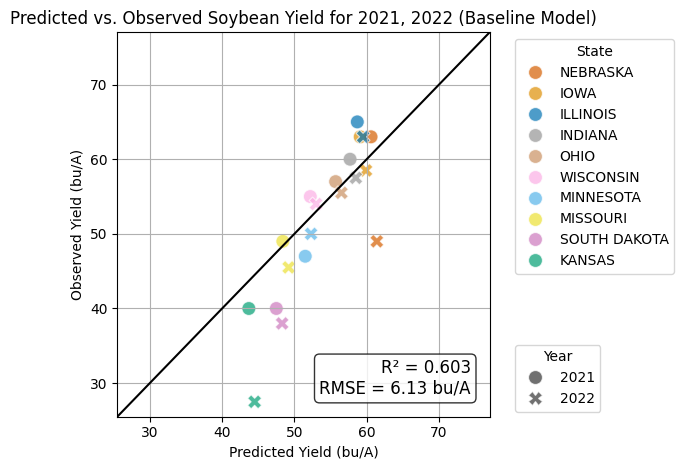

In [ ]:
# Scatter plot with color coding
ax = sns.scatterplot(
    data=pred_vs_actual,
    x='predicted_yield',
    y='yield',
    hue='state_name',
    style='year',
    palette=palette,
    s=100,
    alpha=0.7,
)

# Add 1:1 line
min_val = min(pred_vs_actual['predicted_yield'].min(), pred_vs_actual['yield'].min())-2
max_val = max(pred_vs_actual['predicted_yield'].max(), pred_vs_actual['yield'].max())+12
plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    color='black',
    linestyle='-',
    label='1:1 Line'
)

# Title and labels
plt.title(f'Predicted vs. Observed Soybean Yield for {", ".join(map(str, validation_years))} (Baseline Model)')
plt.xlabel('Predicted Yield (bu/A)')
plt.ylabel('Observed Yield (bu/A)')
plt.grid(True)
plt.xlim(min_val, max_val)
plt.ylim(min_val, max_val)

# Add text box with metrics
plt.text(
    0.95, 0.15, f'R² = {r2:.3f}\nRMSE = {rmse:.2f} bu/A',
    transform=plt.gca().transAxes,
    fontsize=12,
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8),
    ha="right", va="top"
)

# Get legend handles/labels
handles, labels = ax.get_legend_handles_labels()

# Split into state and year entries
state_handles = []
state_labels = []
year_handles = []
year_labels = []

for h, l in zip(handles, labels):
    if l in states_of_interest:
        state_handles.append(h)
        state_labels.append(l)
    elif l in map(str, pred_vs_actual['year'].unique()):
        year_handles.append(h)
        year_labels.append(l)

# First legend: year (style)
legend1 = plt.legend(
    handles=year_handles,
    labels=year_labels,
    title='Year',
    bbox_to_anchor=(1.05, 0.1),
    loc='center left'
)
# Add it manually so it doesn't get overwritten
plt.gca().add_artist(legend1)

# Second legend: state (hue)
plt.legend(
    handles=state_handles,
    labels=state_labels,
    title='State',
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.tight_layout()
plt.show()

Overall, the baseline and RF models show similar aggregate performance (6.13 vs 6.10 bu/A).

However, the RF model exhibits more stable errors across years. In 2022, a poor yield year, the baseline error increases markedly (7.65 vs 4.07 in 2021), while RF remains more consistent. This reflects the limitation of the baseline, which relies on historical yield and struggles in atypical years, whereas RF captures part of the weather-yield relationship.

This difference is also visible at the state level: in 2022, large errors appear for the baseline in high-yield states such as Nebraska (residual = 12.4 bu/A), while RF remains closer to observations (residual = 4.2 bu/A), indicating better robustness to inter-annual and spatial variability.

In [29]:
result = pred_vs_actual.merge(pred_vs_actual_rf, on=['state_name', 'year', 'yield'], suffixes=('_baseline', '_rf'))
result = result[['state_name', 'year', 'yield', 'predicted_yield_baseline', 'predicted_yield_rf']].sort_values(['state_name', 'year'], ascending=[True, True]).reset_index(drop=True)
result["res_baseline"] = result["yield"] - result["predicted_yield_baseline"]
result["res_rf"] = result["yield"] - result["predicted_yield_rf"]
#print(result.head(20))

## Discussion

The RF model achieves mean accuracy comparable to that of the long-term detrended yield average. However, it exhibits greater robustness under atypical weather conditions, resulting in more stable errors across years.

Despite this, the model remains well below the performance reported in the literature. For instance, Joshi et al. 2020 reported a normalized RMSE (nRMSE) of 5.5% for soybean yield prediction across U.S. states using a weather-based ML approach and a similar time series, relying only on temperature and precipitation data. In contrast, our RF model yields a nRMSE of 11.8%.


In [30]:
nrmse_rf = (100 * (rmse_rf / result['yield'].mean())).round(1)
nrmse_baseline = (100 * (rmse / result['yield'].mean())).round(1)
print(f"Normalized RMSE (Baseline): {nrmse_baseline}%")
print(f"Normalized RMSE (RF): {nrmse_rf}%")

Normalized RMSE (Baseline): 11.8%
Normalized RMSE (RF): 11.8%



Here are a number of perspectives to consider if we were to develop a more advanced ML solution.

1. Yield data could be extracted at county level using the USDA NASS QuickStats database, which provides agricultural data published by the National Agricultural Statistics Service (NASS). The model could then be trained at this finer spatial resolution and subsequently aggregated to the state level to smooth prediction errors. This approach would increase the sample size substantially, enabling model fitting across approximately 1,100 counties rather than only 32 states.
2. Weather data could be extracted at an even higher spatial resolutuion leveraging ERA5 dataset (~10km) using ERA5 as a data source. This data could be further subsetted using crop-specific masks derived from the USDA Cropland Data Layer. The feature space could be expanded to a wider range of agronomically relevant variables such as humidity, atmospheric pressure, evaporation, solar radiation, wind, ...
3. Weather variables capture only part of the environmental conditions influencing crop growth. The modeling framework could be extended to incorporate additional data modalities, including soil properties and remote sensing (RS) indices. These inputs could support the design of variables related to crop physiology and management practices, such as irrigation, tillage, planting dates, and harvest timing.
4. Better alignment between crop phenology and input features is needed. In this initial modeling effort, features were aggregated according to generalized US vegetative and reproductive periods, which may not accurately reflect local or year-specific soybean growth cycles. This temporal misalignment likely weakens the signal captured by the model. Leveraging RS data to dynamically estimate phenological stages, or applying simpler thermal time based approaches, could improve the representation of crop development and its relationship to final yield.


## Conclusion

We developped a simple ML model to predict state-level soybean yields using weather-based features. The RF model achieves similar performance to a baseline based on the long-term detrended state-level yield average (RMSE = 6.1 bu/A), while offering improved robustness during years with atypical weather conditions.Specifically, the model generalizes better than the baseline when conditions deviate from historical patterns, as evidenced by its more stable accuracy across years and 15% lower prediction error in 2022, a year characterized by sub-optimal growing conditions.

However, the model's normalized RMSE of 11.8% falls short of state-of-the-art performance reported in peer-reviewed literature (5.5%, Joshi et al. 2020). This gap could come from the following limitations:
- coarse spatial resolution at the state level rather than county-level modeling
- limited feature engineering relative to agronomically relevant thresholds such as heat stress periods and drought indices
- temporal misalignment between phenological windows and actual crop development stages across different regions and years

In summary, a simple weather-based RF model was able to achieve baseline-level accuracy for state-level soybean yield prediction while demonstrating improved robustness under atypical conditions, but remains limited by spatial resolution, feature design, and phenological alignment, resulting in performance well below state-of-the-art possibilities.

## Sources

- Joshi et al., 2020: In-season weather data provide reliable yield estimates of maize and soybean in the US central Corn Belt, https://doi.org/10.1007/s00484-020-02039-z
- Lesk et al., 2016: Influence of extreme weather disasters on global crop production, https://doi.org/10.1038/nature16467 
- Li et al., 2023: A county-level soybean yield prediction framework coupled with XGBoost and multidimensional feature engineering, https://doi.org/10.1016/j.jag.2023.103269
- Onat et al., 2017: The effects of high temperature at the growing period on yield and yield components of soybean variety, https://doi.org/10.17557/tjfc.356210
- QuickStats: https://quickstats.nass.usda.gov
- Standardized Precipitation Index: https://climatedataguide.ucar.edu/climate-data/standardized-precipitation-index-spi
